In [1]:
import torch
from utils.loading_utils import load_model, get_device
from data_loader.dataset import VoxelGridDataset
from matplotlib import pyplot as plt
from os.path import join, basename
import numpy as np
import json
import argparse
from utils.timers import cuda_timers
import time
import shutil
import os
from psf_depth_reconstructor import PSFDepthReconstructor
from options.inference_options import set_depth_inference_options
from data_loader.dataset import UpsampledFramesDataset
from types import SimpleNamespace
from model.unet import *
from types import SimpleNamespace
import torch
from model.model import E2VIDRecurrentPSF  
from model.model import E2VIDRecurrent
from model import unet as unet_mod          
from torch.utils.data import DataLoader
from data_loader.dataset import SequenceUpsampledFramesDataset
import matplotlib.image as mpimg
from model.unet import compute_event_frame, event_frames_to_voxel_grid
import torch.nn.functional as F

In [2]:
## Defind Plot Grid Funcion
def plotgrid(stack):
    num_psf = stack.shape[0]  

    ncols = 5  # 원하는대로
    nrows = (num_psf + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(2*ncols, 2*nrows))

    for i in range(num_psf):
        row, col = divmod(i, ncols)
        ax = axes[row, col]
        ax.imshow(stack[i].detach().numpy(), cmap='gray')
        ax.set_title(f"Depth {i+2}")   # depth index는 2부터일 수도 있으니 맞게 조절
        ax.axis('off')

    for i in range(num_psf, nrows*ncols):
        row, col = divmod(i, ncols)
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
%load_ext autoreload
%autoreload 2

PATH_TO_MODEL = '/home/yl3836/mono_event/rpg_e2depth/e2depth/saved/1027_sparse_v2_two_points_[space_7]_0_75/example_psf/checkpoint-epoch200-loss-0.0068.pth.tar'
#PATH_TO_MODEL = '/home/yl3836/mono_event/rpg_e2depth/e2depth/saved/1025_sparse_v2_one_points/example_psf/checkpoint-epoch088-loss-0.0069.pth.tar'
tag = " [1027_two_points_space_7]"
#PATH_TO_MODEL = '/home/yl3836/mono_event/rpg_e2depth/e2depth/saved/0912_off_P21_D30_rotated_0_5_2_0/example_psf/model_best.pth.tar'
BASE_FOLDER = '/home/yl3836/DENSE/valid_sparse_v2/valid_seed_50/'
#BASE_FOLDER = '/home/yl3836/DENSE/train_upsampled/train_sequence_03_town04/'
USE_GPU = True

args = SimpleNamespace(
    path_to_model=PATH_TO_MODEL,
    base_folder=BASE_FOLDER,
    use_gpu=USE_GPU,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
#### Load model
PATH = args.path_to_model
ckpt = torch.load(PATH, map_location='cpu')

#### Same config as used in training
cfg = dict(num_bins=5, skip_type='sum', recurrent_block_type='convlstm',
           num_encoders=3, base_num_channels=32,
           num_residual_blocks=2, use_upsample_conv=True, norm='none', psf_init='random')



#### Top-level model class
model = E2VIDRecurrentPSF(cfg)


######## Loading the weights
model.load_state_dict(ckpt['state_dict'])  

######## Evaluation mode : disable dropout
model.eval()


#### Load optimized psf
net = model.unetrecurrentpsf

/tmp/ipykernel_4152185/3705782054.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(PATH, map_location='cpu')


Using UpsampleConvLayer (slow, but no checkerboard artefacts)


/home/yl3836/mono_event/rpg_e2depth/e2depth/model/unet.py:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  th = torch.tensor(theta_deg, device=device, dtype=dtype) * torch.pi / 180
/home/yl3836/mono_event/rpg_e2depth/e2depth/model/unet.py:408: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  psf_list.append(torch.tensor(conv,dtype = torch.float32))


In [22]:
#### CPU safe collate copied from train.py 

def _to_device(x, device):
    if isinstance(x, torch.Tensor):
        return x.to(device, non_blocking=True)
    if isinstance(x, dict):
        return {k: _to_device(v, device) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return type(x)(_to_device(v, device) for v in x)
    return x

def collate_keep_sequence(batch, device):
    # batch: [N] where each item is a sequence [L] of dicts
    return _to_device(batch, device)

In [23]:
device = 'cpu' 

unet_mod.gpu = device   # used by UNetRecurrentPSF to move tensors
model.to(device).eval() 

#### load dataset
ds = SequenceUpsampledFramesDataset(
    base_folder=BASE_FOLDER,
    event_folder='',
    depth_folder='imgs',
    frame_folder='frames',
    sequence_length=20, step_size=1, normalize=True
)

loader = DataLoader(
    ds, batch_size=1, shuffle=False,
    collate_fn=lambda b: collate_keep_sequence(b, device),
    num_workers=0, pin_memory=False
)

batch = next(iter(loader))                

##### Forming sequence, copied from lstm.py
sequence = list(map(list, zip(*batch)))   
cur_input   = sequence[0]                 
prev_states = None

#### This is the forward model of top-level model
with torch.no_grad():
    voxel, frame, pred, states, timing = model.unetrecurrentpsf(cur_input, prev_states, downsample=False, measure_time = True)
print(voxel.shape, frame.shape, pred.shape)

torch.Size([1, 5, 240, 346]) torch.Size([9, 1, 240, 346]) torch.Size([1, 1, 240, 346])


#### Load depth n Check

Text(0.5, 1.0, 'Ground Truth Depth Map')

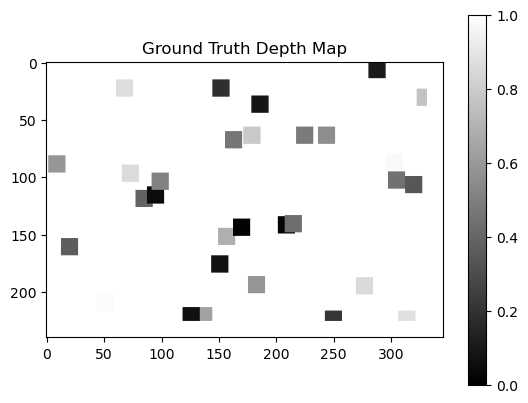

In [24]:
# GT depth map that converted into log scale
plt.imshow(frame[1].squeeze().squeeze(), cmap = 'gray', vmin=0, vmax=1)  # GT depth map
plt.colorbar()
plt.title("Ground Truth Depth Map")

In [25]:
print(frame[1].shape)

torch.Size([1, 240, 346])


Text(0.5, 1.0, 'Predicted Depth Map [1026_rotated_0_75_2_0]')

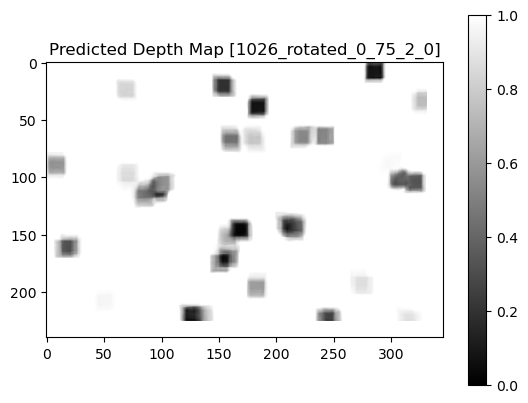

In [26]:
#### Prediction of the network in log scale
plt.imshow(pred.squeeze().squeeze(), cmap = 'gray', vmin=0, vmax=1)  # Predicted depth map
plt.colorbar()
plt.title("Predicted Depth Map" +tag)

In [27]:
def scale_invariant_loss(y_input, y_target, weight = 1.0, n_lambda = 1.0):
    log_diff = y_input - y_target
    is_nan = torch.isnan(log_diff)
    return weight * ((log_diff[~is_nan]**2).mean()-(n_lambda*(log_diff[~is_nan].mean())**2))


scale_invariant_loss(frame[1], pred.squeeze().squeeze())

tensor(0.0074)

In [28]:
def mse(pred, target):
    return ((pred - target) ** 2).mean()


mse(frame[1], pred.squeeze().squeeze())

tensor(0.0074)

In [29]:
val_loader = loader

In [30]:
with torch.no_grad():
    voxel, frame, pred, states, timing = model.unetrecurrentpsf(cur_input, prev_states, downsample=False, measure_time = True)
print(voxel.shape, frame.shape, pred.shape)

torch.Size([1, 5, 240, 346]) torch.Size([9, 1, 240, 346]) torch.Size([1, 1, 240, 346])


In [31]:
# # --- set env BEFORE torch import ---
# import os
# os.environ["OMP_NUM_THREADS"] = "1"
# os.environ["MKL_NUM_THREADS"] = "1"
# os.environ["OPENBLAS_NUM_THREADS"] = "1"
# os.environ["NUMEXPR_NUM_THREADS"] = "1"

# import torch
# import torch.nn.functional as F
# from torch.utils.data import DataLoader

# # Thread caps inside PyTorch
# torch.set_num_threads(1)
# torch.set_num_interop_threads(1)

# # Speed toggles
# torch.backends.cudnn.benchmark = True
# if hasattr(torch, "set_float32_matmul_precision"):
#     torch.set_float32_matmul_precision("high")

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = model.to(device)
# use_amp = (device.type == "cuda")

# # Example DataLoader (replace `dataset` with yours)
# # dataset __getitem__ should return (cur_input, y_true)
# # loader = DataLoader(
# #     dataset,
# #     batch_size=1,              # or >1 if your model supports it
# #     shuffle=False,
# #     num_workers=0,             # keep it single-process to avoid CPU spikes
# #     pin_memory=(device.type == "cuda"),
# #     drop_last=False,
# # )
# ds = SequenceUpsampledFramesDataset(
#     base_folder=BASE_FOLDER,
#     event_folder='',
#     depth_folder='imgs',
#     frame_folder='frames',
#     sequence_length=20, step_size=1, normalize=True
# )

# loader = DataLoader(
#     ds, batch_size=1, shuffle=False,
#     collate_fn=lambda b: collate_keep_sequence(b, device),
#     num_workers=0, pin_memory=False
# )

# batch = next(iter(loader))      

# def ensure_batched(x: torch.Tensor) -> torch.Tensor:
#     return x if x.dim() >= 3 else x.unsqueeze(0)

# mse_sum     = torch.zeros((), device=device)
# mse_sq_sum  = torch.zeros((), device=device)
# count_items = 0

# model.eval()
# with torch.inference_mode():
#     autocast_ctx = (
#         torch.cuda.amp.autocast(enabled=use_amp, dtype=torch.float16)
#         if use_amp else torch.no_grad()
#     )
#     with autocast_ctx:
#         for cur_input, y_true in loader:
#             # Move to device
#             cur_input = cur_input.to(device, non_blocking=True)
#             y_true    = y_true.to(device, non_blocking=True)

#             # ---- If your model is a plain forward():
#             # pred = model(cur_input)

#             # ---- If using your recurrent call:
#             voxel, frame, pred, states = model.unetrecurrentpsf(
#                 cur_input, prev_states=None, downsample=False, measure_time=False
#             )
#             # y_true from your dataset OR from frame[1]; choose one:
#             # y_true = frame[1].to(device, non_blocking=True)

#             # Ensure float32 for loss math (safe after AMP)
#             y_pred = pred.float().squeeze()
#             y_true = y_true.float().squeeze()

#             y_pred = ensure_batched(y_pred)
#             y_true = ensure_batched(y_true)

#             # Per-item MSE across all non-batch dims
#             diff = (y_pred - y_true).pow(2)
#             mse_per_item = diff.flatten(1).mean(dim=1)  # shape [B]

#             mse_sum     += mse_per_item.sum()
#             mse_sq_sum  += (mse_per_item ** 2).sum()
#             count_items += mse_per_item.numel()

# # Final stats
# count = max(count_items, 1)
# mean_mse = (mse_sum / count).item()
# var_pop = (mse_sq_sum / count) - (mean_mse ** 2)
# std_pop = float(torch.clamp(var_pop, min=0).sqrt().item())
# if count > 1:
#     var_sample = (mse_sq_sum - count * (mean_mse ** 2)) / (count - 1)
#     std_sample = float(torch.clamp(var_sample, min=0).sqrt().item())
# else:
#     std_sample = float("nan")

# print(f"Items evaluated: {count}")
# print(f"Mean MSE: {mean_mse:.6f}")
# print(f"Std MSE (population): {std_pop:.6f}")
# print(f"Std MSE (sample):     {std_sample:.6f}")


In [32]:
# # ==== Fast Mean + Std MSE over validation set ====
# # ---- put these BEFORE importing torch (critical) ----
# import os
# os.environ["OMP_NUM_THREADS"] = "1"        # <<< cap OpenMP threads
# os.environ["MKL_NUM_THREADS"] = "1"        # <<< cap MKL threads
# os.environ["OPENBLAS_NUM_THREADS"] = "1"   # <<< cap OpenBLAS threads
# os.environ["NUMEXPR_NUM_THREADS"] = "1"    # <<< cap numexpr threads

# import torch
# import torch.nn.functional as F
# import math

# # Hard-cap PyTorch CPU threading as well
# torch.set_num_threads(1)            # <<< intra-op = 1
# torch.set_num_interop_threads(1)    # <<< inter-op = 1

# # Speed toggles
# torch.backends.cudnn.benchmark = True
# if hasattr(torch, "set_float32_matmul_precision"):
#     torch.set_float32_matmul_precision("high")

# # Prefer GPU if present to keep CPU usage tiny
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # <<<
# model = model.to(device)                                               # <<<
# use_amp = (device.type == "cuda")

# # If you build the DataLoader here, keep it single-worker to avoid extra CPU procs
# # from torch.utils.data import DataLoader
# # loader = DataLoader(
# #     ds, batch_size=1, shuffle=False,
# #     num_workers=0,                               # <<< single worker (no extra processes)
# #     pin_memory=(device.type == "cuda"),
# #     prefetch_factor=2, persistent_workers=False, # <<< don't persist workers
# #     collate_fn=lambda b: collate_keep_sequence(b, device),
# #     drop_last=False
# # )

# def ensure_batched(x: torch.Tensor) -> torch.Tensor:
#     # Make sure there is a batch dim: [B, ...]
#     return x if x.dim() >= 3 else x.unsqueeze(0)

# # Running sums (stay on GPU)
# mse_sum     = torch.zeros((), device=device)  # sum of per-item MSEs
# mse_sq_sum  = torch.zeros((), device=device)  # sum of squares of per-item MSEs
# count_items = 0

# model.eval()

# with torch.inference_mode():
#     with (torch.cuda.amp.autocast(enabled=use_amp, dtype=torch.float16) if use_amp else torch.no_grad()):
#         for batch in loader:
#             sequence    = list(map(list, zip(*batch)))
#             cur_input   = sequence[0]
#             prev_states = None

#             voxel, frame, pred, states = model.unetrecurrentpsf(
#                 cur_input, prev_states, downsample=False, measure_time=False
#             )

#             y_pred = pred.float().to(device, non_blocking=True).squeeze()     # <<<
#             y_true = frame[1].float().to(device, non_blocking=True).squeeze() # <<<

#             y_pred = ensure_batched(y_pred)
#             y_true = ensure_batched(y_true)

#             diff = (y_pred - y_true).pow(2)
#             mse_per_item = diff.flatten(1).mean(dim=1)

#             mse_sum    += mse_per_item.sum()
#             mse_sq_sum += (mse_per_item ** 2).sum()
#             count_items += mse_per_item.numel()

# count = max(count_items, 1)
# mean_mse = (mse_sum / count).item()
# var_pop = (mse_sq_sum / count) - (mean_mse ** 2)
# std_pop = float(torch.clamp(var_pop, min=0).sqrt().item())
# if count > 1:
#     var_sample = (mse_sq_sum - count * (mean_mse ** 2)) / (count - 1)
#     std_sample = float(torch.clamp(var_sample, min=0).sqrt().item())
# else:
#     std_sample = float("nan")

# print(f"Dataset: {BASE_FOLDER}")
# print(f"Items evaluated: {count}")
# print(f"Mean MSE: {mean_mse:.6f}")
# print(f"Std MSE (population): {std_pop:.6f}")
# print(f"Std MSE (sample):     {std_sample:.6f}")


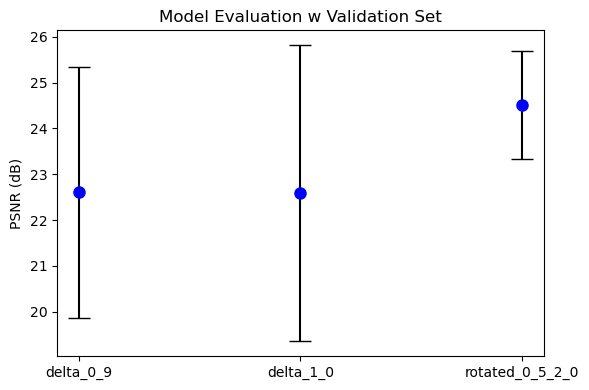

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Example data
models = ["delta_0_9", "delta_1_0", "rotated_0_5_2_0"]  # Replace with your model names
mean_mse = [0.005491, 0.005513, 0.003541]   # Replace with your values
std_mse = [0.003455, 0.004098, 0.000963]   # Replace with your values
psnr = [20 * np.log10(1.0 / np.sqrt(mse)) for mse in mean_mse]
std_psnr = [10 * (std / (mse * np.log(10))) for mse, std in zip(mean_mse, std_mse)]

# X positions
x = np.arange(len(models))

# Plot
plt.figure(figsize=(6, 4))
plt.errorbar(x, psnr, yerr=std_psnr, fmt='o', capsize=8, markersize=8,
             color="blue", ecolor="black", elinewidth=1.5)

# Labels and title
plt.xticks(x, models)
plt.ylabel("PSNR (dB)")
plt.title("Model Evaluation w Validation Set")

plt.tight_layout()
plt.show()


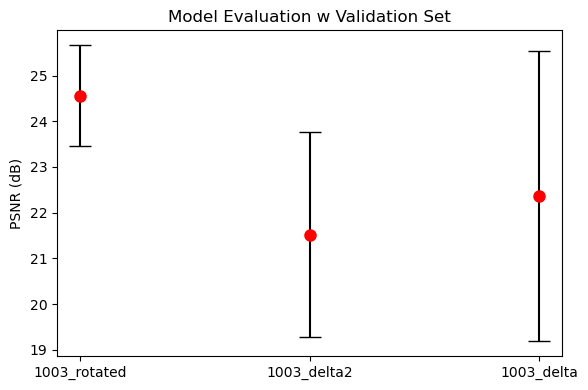

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Example data
models = ["1003_rotated", "1003_delta2", "1003_delta"]  # Replace with your model names
mean_mse = [0.003498, 0.007043, 0.005803]   # Replace with your values
std_mse = [0.000888, 0.003650, 0.004246]   # Replace with your values
psnr = [20 * np.log10(1.0 / np.sqrt(mse)) for mse in mean_mse]
std_psnr = [10 * (std / (mse * np.log(10))) for mse, std in zip(mean_mse, std_mse)]

# X positions
x = np.arange(len(models))

# Plot
plt.figure(figsize=(6, 4))
plt.errorbar(x, psnr, yerr=std_psnr, fmt='o', capsize=8, markersize=8,
             color="red", ecolor="black", elinewidth=1.5)

# Labels and title
plt.xticks(x, models)
plt.ylabel("PSNR (dB)")
plt.title("Model Evaluation w Validation Set")

plt.tight_layout()
plt.show()


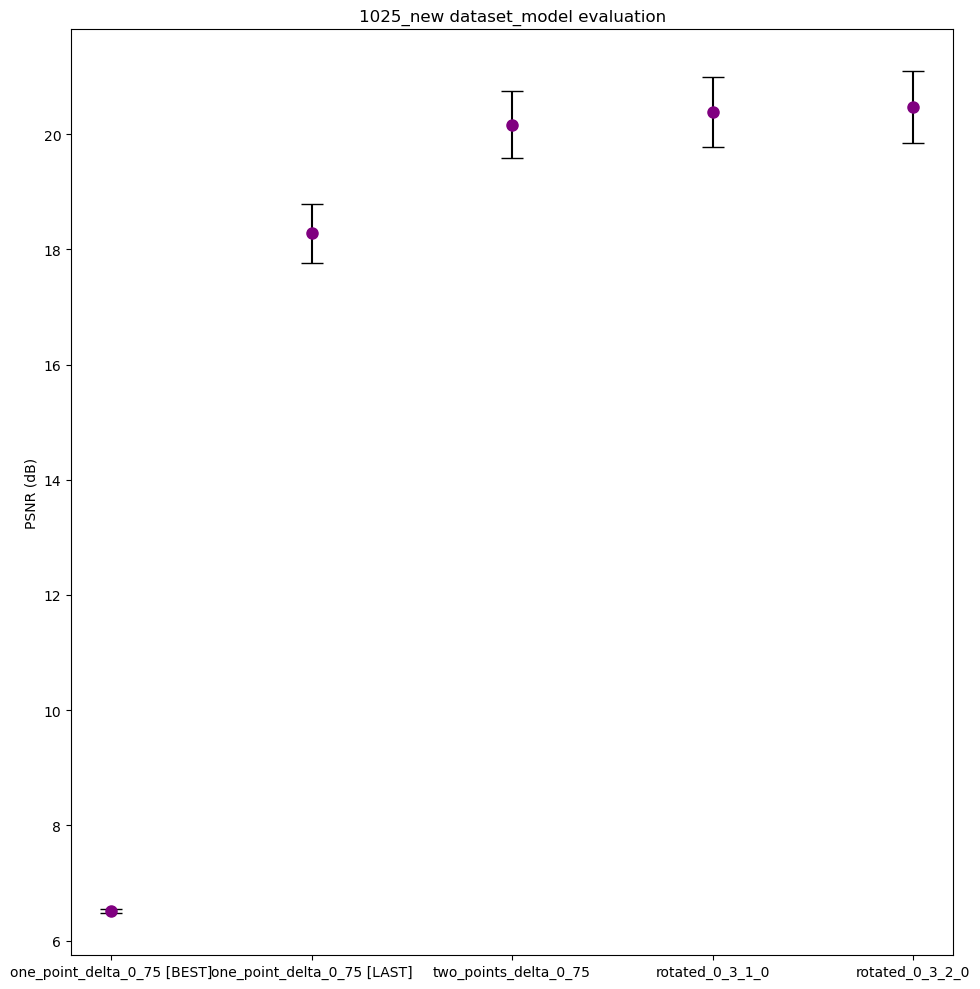

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Example data
models = ["one_point_delta_0_75 [BEST]", "one_point_delta_0_75 [LAST]", "two_points_delta_0_75", "rotated_0_3_1_0", "rotated_0_3_2_0"]  # Replace with your model names
mean_mse = [0.223355, 0.014868,0.009621, 0.009146,0.008969 ]   # Replace with your values
std_mse = [0.001706,0.001746,0.001303, 0.001281, 0.001278 ]   # Replace with your values
psnr = [20 * np.log10(1.0 / np.sqrt(mse)) for mse in mean_mse]
std_psnr = [10 * (std / (mse * np.log(10))) for mse, std in zip(mean_mse, std_mse)]

# X positions
x = np.arange(len(models))

# Plot
plt.figure(figsize=(10, 10))
plt.errorbar(x, psnr, yerr=std_psnr, fmt='o', capsize=8, markersize=8,
             color="purple", ecolor="black", elinewidth=1.5)

# Labels and title
plt.xticks(x, models)
plt.ylabel("PSNR (dB)")
plt.title("1025_new dataset_model evaluation")

plt.tight_layout()
plt.show()

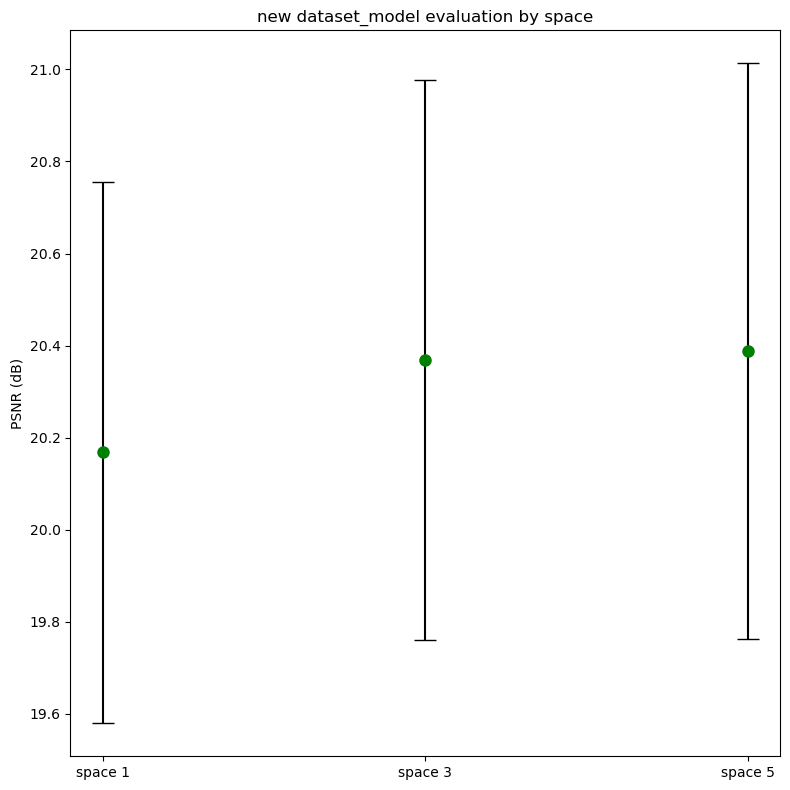

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Example data
models = ["space 1", "space 3", "space 5"]  # Replace with your model names
mean_mse = [0.009621, 0.009186, 0.009146 ]   # Replace with your values
std_mse = [0.001303,0.001285,0.001317 ]   # Replace with your values
psnr = [20 * np.log10(1.0 / np.sqrt(mse)) for mse in mean_mse]
std_psnr = [10 * (std / (mse * np.log(10))) for mse, std in zip(mean_mse, std_mse)]

# X positions
x = np.arange(len(models))

# Plot
plt.figure(figsize=(8,8))
plt.errorbar(x, psnr, yerr=std_psnr, fmt='o', capsize=8, markersize=8,
             color="green", ecolor="black", elinewidth=1.5)

# Labels and title
plt.xticks(x, models)
plt.ylabel("PSNR (dB)")
plt.title("new dataset_model evaluation by space")

plt.tight_layout()
plt.show()

In [35]:
# ==== Fast Mean + Std MSE over validation set ====
import os
import torch
import torch.nn.functional as F
import math

# --- MINIMAL CHANGE: cap CPU usage on login nodes ---
torch.set_num_threads(1)            # <<< limit intra-op threads
torch.set_num_interop_threads(1)    # <<< limit inter-op parallelism

# (Optional but harmless) also hint BLAS libs; OK even after imports
os.environ.setdefault("OMP_NUM_THREADS", "1")       # <<<
os.environ.setdefault("MKL_NUM_THREADS", "1")       # <<<
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")  # <<<
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")   # <<<

# Speed toggles
torch.backends.cudnn.benchmark = True
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

device = next(model.parameters()).device
use_amp = (device.type == "cuda")

# ---- OPTIONAL: keep DataLoader from spawning CPU workers ----
# If you (re)build the loader here, keep num_workers=0 to avoid extra CPU:
# from torch.utils.data import DataLoader
# loader = DataLoader(
#     ds, batch_size=1, shuffle=False,
#     num_workers=0,                      # <<< single-process loading (lowest CPU)
#     pin_memory=(device.type=="cuda"),
#     prefetch_factor=2, persistent_workers=False,
#     collate_fn=lambda b: collate_keep_sequence(b, device),
#     drop_last=False
# )

def ensure_batched(x: torch.Tensor) -> torch.Tensor:
    # Make sure there is a batch dim: [B, ...]
    return x if x.dim() >= 3 else x.unsqueeze(0)

# Running sums (stay on GPU)
mse_sum     = torch.zeros((), device=device)  # sum of per-item MSEs
mse_sq_sum  = torch.zeros((), device=device)  # sum of squares of per-item MSEs
count_items = 0

model.eval()
autocast_ctx = torch.cuda.amp.autocast(enabled=use_amp, dtype=torch.float16) if use_amp else torch.no_grad()

with torch.inference_mode():
    with (torch.cuda.amp.autocast(enabled=use_amp, dtype=torch.float16) if use_amp else torch.no_grad()):
        for batch in loader:
            sequence    = list(map(list, zip(*batch)))
            cur_input   = sequence[0]
            prev_states = None

            voxel, frame, pred, states = model.unetrecurrentpsf(
                cur_input, prev_states, downsample=False, measure_time=False
            )

            y_pred = pred.float().to(device, non_blocking=True).squeeze()
            y_true = frame[1].float().to(device, non_blocking=True).squeeze()

            y_pred = ensure_batched(y_pred)
            y_true = ensure_batched(y_true)

            diff = (y_pred - y_true).pow(2)
            mse_per_item = diff.flatten(1).mean(dim=1)

            mse_sum    += mse_per_item.sum()
            mse_sq_sum += (mse_per_item ** 2).sum()
            count_items += mse_per_item.numel()

count = max(count_items, 1)
mean_mse = (mse_sum / count).item()
var_pop = (mse_sq_sum / count) - (mean_mse ** 2)
std_pop = float(torch.clamp(var_pop, min=0).sqrt().item())
if count > 1:
    var_sample = (mse_sq_sum - count * (mean_mse ** 2)) / (count - 1)
    std_sample = float(torch.clamp(var_sample, min=0).sqrt().item())
else:
    std_sample = float("nan")

print(f"Dataset: {BASE_FOLDER}")
print(f"Items evaluated: {count}")
print(f"Mean MSE: {mean_mse:.6f}")
print(f"Std MSE (population): {std_pop:.6f}")
print(f"Std MSE (sample):     {std_sample:.6f}")


RuntimeError: Error: cannot set number of interop threads after parallel work has started or set_num_interop_threads called

In [36]:
# ==== Fast Mean + Std MSE over validation set ====
import torch
import torch.nn.functional as F
import math
import os

# Speed toggles
torch.backends.cudnn.benchmark = True
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

device = next(model.parameters()).device
use_amp = (device.type == "cuda")

# ---- OPTIONAL: speed up the DataLoader if you used small/zero workers before ----
# Rebuild loader with more workers & pinned memory (adjust workers to your CPU)
# loader = DataLoader(
#     ds, batch_size=1, shuffle=False,
#     num_workers=min(4, os.cpu_count() or 4),
#     pin_memory=True, prefetch_factor=2, persistent_workers=True,
#     collate_fn=lambda b: collate_keep_sequence(b, device),
#     drop_last=False
# )

def ensure_batched(x: torch.Tensor) -> torch.Tensor:
    # Make sure there is a batch dim: [B, ...]
    return x if x.dim() >= 3 else x.unsqueeze(0)

# Running sums (stay on GPU)
mse_sum     = torch.zeros((), device=device)  # sum of per-item MSEs
mse_sq_sum  = torch.zeros((), device=device)  # sum of squares of per-item MSEs
count_items = 0

model.eval()
autocast_ctx = torch.cuda.amp.autocast(enabled=use_amp, dtype=torch.float16) if use_amp else torch.no_grad()

with torch.inference_mode():
    with (torch.cuda.amp.autocast(enabled=use_amp, dtype=torch.float16) if use_amp else torch.no_grad()):
        for batch in loader:
            # Same packing pattern as your notebook
            sequence   = list(map(list, zip(*batch)))
            cur_input  = sequence[0]
            prev_states = None

            # Forward (no timing)
            voxel, frame, pred, states = model.unetrecurrentpsf(
                cur_input, prev_states, downsample=False, measure_time=False
            )

            # Prepare tensors
            y_pred = pred.float().to(device).squeeze()
            y_true = frame[1].float().to(device).squeeze()

            # Ensure we have [B, ...] to compute per-item MSEs in a vectorized way
            y_pred = ensure_batched(y_pred)
            y_true = ensure_batched(y_true)

            # Per-item MSE across pixels: flatten per item, mean over pixels
            diff = (y_pred - y_true).pow(2)
            mse_per_item = diff.flatten(1).mean(dim=1)   # shape [B]

            # Update running sums on GPU (no .item(), no host sync)
            mse_sum    += mse_per_item.sum()
            mse_sq_sum += (mse_per_item ** 2).sum()
            count_items += mse_per_item.numel()

# Move small scalars to CPU just once
count = max(count_items, 1)
mean_mse = (mse_sum / count).item()
# population std
var_pop = (mse_sq_sum / count) - (mean_mse ** 2)
std_pop = float(torch.clamp(var_pop, min=0).sqrt().item())
# sample std (unbiased) if count > 1
if count > 1:
    var_sample = (mse_sq_sum - count * (mean_mse ** 2)) / (count - 1)
    std_sample = float(torch.clamp(var_sample, min=0).sqrt().item())
else:
    std_sample = float("nan")

print(f"Dataset: {BASE_FOLDER}")
print(f"Items evaluated: {count}")
print(f"Mean MSE: {mean_mse:.6f}")
print(f"Std MSE (population): {std_pop:.6f}")
print(f"Std MSE (sample):     {std_sample:.6f}")


Dataset: /home/yl3836/DENSE/valid_sparse_v2/valid_seed_50/
Items evaluated: 882
Mean MSE: 0.008969
Std MSE (population): 0.001278
Std MSE (sample):     0.001279


In [ ]:
print(psfs.shape)
# arb_psfs = torch.zeros_like(psfs)
arb_psfs = []

num_depths = psfs.shape[0]
psf_size = psfs.shape[-1]
center = psf_size //2


angles = torch.linspace(0,90, steps=num_depths)
for theta in angles:
    base = torch.zeros((psf_size, psf_size), dtype=torch.float32)
    base[center, center] = 10
    gauss = gaussian_filter(base.numpy(), sigma=[1.0, 4.0]) 
    rotated = rotate(gauss, angle=float(theta), reshape=False, order=1, mode='nearest')
    rotated /= rotated.sum()

    arb_psfs.append(torch.tensor(rotated *100, dtype=torch.float32))

arb_psfs = torch.stack(arb_psfs)
arb_psfs = arb_psfs.unsqueeze(1)  # (D, 1, k, k)
print(arb_psfs.shape)


# Display arb_psfs

psf_stack = arb_psfs.squeeze()

num_psf = psf_stack.shape[0]  
ncols = 5  # 원하는대로
nrows = (num_psf + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(2*ncols, 2*nrows))

for i in range(num_psf):
    row, col = divmod(i, ncols)
    ax = axes[row, col]
    im = ax.imshow(psf_stack[i].detach().numpy(), cmap='jet')
    ax.set_title(f"Depth {i+2}")   # depth index는 2부터일 수도 있으니 맞게 조절
    ax.axis('off')
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    cbar.ax.tick_params(labelsize=8)

for i in range(num_psf, nrows*ncols):
    row, col = divmod(i, ncols)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print(arb_psfs.max())

In [15]:
psfs = torch.zeros((30, 1, 31, 31), dtype=torch.float32)

In [ ]:
print(psfs.shape)
# arb_psfs = torch.zeros_like(psfs)
arb_psfs = []

num_depths = psfs.shape[0]
psf_size = psfs.shape[-1]
center = psf_size //2


angles = torch.linspace(0,90, steps=num_depths)
for theta in angles:
    psf_list = []

    # --------- simple knobs ----------
    separation_px = 8    # distance between the two peaks (in pixels)
    sigma = 0.7          # gaussian blur to turn impulses into gaussians
    # ---------------------------------

    # Build a base image with two impulses placed horizontally around center
    base = np.zeros((psf_size, psf_size), dtype=np.float32)
    center = psf_size // 2

    # Use integer offsets for simplicity; psf_size odd is recommended
    off = int(round(separation_px / 2))
    left_x  = center - off
    right_x = center + off

    # Guard against going out of bounds if separation_px is large
    left_x  = max(0, min(psf_size - 1, left_x))
    right_x = max(0, min(psf_size - 1, right_x))

    base[center, left_x]  = 1.0
    base[center, right_x] = 1.0

    # Turn the impulses into two Gaussians
    gauss_two = gaussian_filter(base, sigma=sigma)

    for theta in angles:
        rotated = rotate(gauss_two, angle=float(theta), reshape=False, order=1, mode='nearest')
        rotated = (rotated-rotated.min())/(rotated.max() - rotated.min())  # keep it normalized
        psf_list.append(torch.tensor(rotated, dtype=torch.float32))


    psf_stack = torch.stack(psf_list, dim=0)


# Display arb_psfs

psf_stack = psf_stack.squeeze()

num_psf = psf_stack.shape[0]  
ncols = 5  # 원하는대로
nrows = (num_psf + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(2*ncols, 2*nrows))

for i in range(num_psf):
    row, col = divmod(i, ncols)
    ax = axes[row, col]
    im = ax.imshow(psf_stack[i].detach().numpy(), cmap='jet')
    ax.set_title(f"Depth {i+2}")   # depth index는 2부터일 수도 있으니 맞게 조절
    ax.axis('off')
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    cbar.ax.tick_params(labelsize=8)

for i in range(num_psf, nrows*ncols):
    row, col = divmod(i, ncols)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()


torch.Size([21, 21])


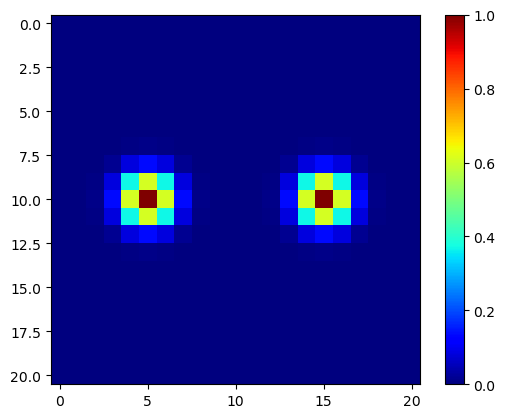

In [32]:
import torch
import torch.nn.functional as F

# Start with delta image
img = torch.zeros(1, 1, 21, 21)
img[0, 0, 10, 10-5] = 1.0   # left delta
img[0, 0, 10, 10+5] = 1.0   # right delta (10±3.5 rounded)

# Create Gaussian kernel
def gaussian_kernel(size=21, sigma=1.0):
    x = torch.arange(size) - size//2
    y = torch.arange(size) - size//2
    X, Y = torch.meshgrid(x, y, indexing="ij")
    g = torch.exp(-(X**2 + Y**2) / (2*sigma**2))
    return (g-g.min())/g.max()

kernel = gaussian_kernel().unsqueeze(0).unsqueeze(0)

# Convolve delta image with Gaussian
img = F.conv2d(img, kernel, padding=21//2)

print(img.squeeze().squeeze().shape)
plt.imshow(img.squeeze().squeeze(), cmap='jet')
plt.colorbar()

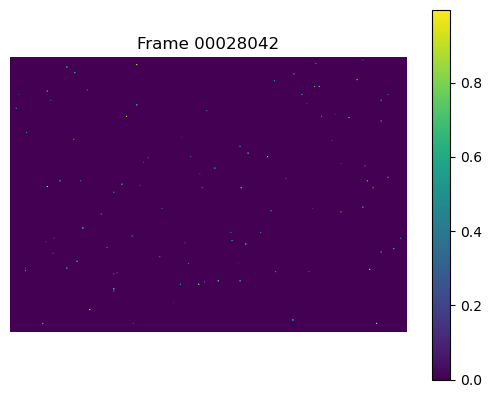

0.99607843


In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 이미지 경로
img_path = "/home/yl3836/DENSE/train_sparse/train_seed_42/imgs/00000002.png"

# 이미지 읽기
img = mpimg.imread(img_path)

# 이미지 plot
plt.imshow(img)
plt.axis('off')  # 축 제거
plt.title("Frame 00028042")
plt.colorbar()
plt.show()

print(img.max().max())
